<a href="https://colab.research.google.com/github/SimplyNameless/aqualimpia-analisis/blob/main/analisis_aqualimpia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/SimplyNameless/aqualimpia-analisis.git
%cd aqualimpia-analisis
!ls data

Cloning into 'aqualimpia-analisis'...
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 11 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (11/11), 24.02 KiB | 2.18 MiB/s, done.
/content/aqualimpia-analisis
dataset_set_A_aguas_residuales.xlsx


In [2]:
import pandas as pd

df = pd.read_excel('data/dataset_set_A_aguas_residuales.xlsx')

print(df.shape)
df.info()
df.head()

(200, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fecha_registro        200 non-null    object 
 1   planta                200 non-null    object 
 2   caudal_entrada_m3_d   200 non-null    int64  
 3   DBO_entrada_mg_L      200 non-null    int64  
 4   SST_entrada_mg_L      200 non-null    int64  
 5   pH_entrada            200 non-null    float64
 6   energia_aeracion_kWh  200 non-null    float64
 7   lodos_generados_kg_d  200 non-null    float64
 8   DBO_salida_mg_L       200 non-null    float64
 9   cumplimiento_norma    200 non-null    int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 15.8+ KB


,fecha_registro,planta,caudal_entrada_m3_d,DBO_entrada_mg_L,SST_entrada_mg_L,pH_entrada,energia_aeracion_kWh,lodos_generados_kg_d,DBO_salida_mg_L,cumplimiento_norma
0,2025-08-17,Planta Sur,6562,271,324,7.12,1261.1,440.3,40.0,0
1,2025-09-07,Planta Sur,5336,322,230,7.01,1629.3,561.2,26.8,1
2,2025-07-26,Planta Norte,5755,318,282,6.79,1469.2,441.6,45.2,0
3,2025-10-27,Planta Centro,6840,216,167,7.01,1764.8,560.0,38.0,0
4,2025-09-06,Planta Centro,6803,326,200,7.55,1409.3,654.0,32.1,0


In [3]:
df['fecha_registro'] = pd.to_datetime(df['fecha_registro'], format='%Y-%m-%d')

print(df['fecha_registro'].dtype)
print('Desde:', df['fecha_registro'].min())
print('Hasta:', df['fecha_registro'].max())

datetime64[ns]
Desde: 2025-07-01 00:00:00
Hasta: 2025-10-28 00:00:00


In [4]:
df['eficiencia_remocion_pct'] = (
    (df['DBO_entrada_mg_L'] - df['DBO_salida_mg_L']) / df['DBO_entrada_mg_L'] * 100
).round(2)

df['eficiencia_remocion_pct'].describe()

,eficiencia_remocion_pct
count,200.00000
mean,87.09290
std,3.09898
min,80.69000
25%,84.75250
50%,87.00000
75%,89.68000
max,93.43000


In [5]:
variables = ['caudal_entrada_m3_d', 'DBO_entrada_mg_L', 'SST_entrada_mg_L',
             'pH_entrada', 'energia_aeracion_kWh', 'lodos_generados_kg_d',
             'eficiencia_remocion_pct', 'DBO_salida_mg_L']

df[variables].corr()['DBO_salida_mg_L'].sort_values(ascending=False).round(3)

,DBO_salida_mg_L
DBO_salida_mg_L,1.000
DBO_entrada_mg_L,0.759
energia_aeracion_kWh,0.144
lodos_generados_kg_d,0.138
caudal_entrada_m3_d,0.104
SST_entrada_mg_L,0.066
pH_entrada,-0.135
eficiencia_remocion_pct,-0.632


In [9]:
resumen_plantas = df.groupby('planta').agg(
    registros=('planta', 'count'),
    DBO_entrada_prom=('DBO_entrada_mg_L', 'mean'),
    DBO_salida_prom=('DBO_salida_mg_L', 'mean'),
    eficiencia_prom=('eficiencia_remocion_pct', 'mean'),
    tasa_cumplimiento_pct=('cumplimiento_norma', 'mean')
)

resumen_plantas['tasa_cumplimiento_pct'] = resumen_plantas['tasa_cumplimiento_pct'] * 100
resumen_plantas = resumen_plantas.round(2)
resumen_plantas

,registros,DBO_entrada_prom,DBO_salida_prom,eficiencia_prom,tasa_cumplimiento_pct
planta,,,,,
Planta Centro,75,285.19,35.90,87.51,22.67
Planta Norte,71,275.85,36.56,86.65,16.90
Planta Sur,54,278.80,36.06,87.10,29.63


In [10]:
from scipy.stats import chi2_contingency

tabla = pd.crosstab(df['planta'], df['cumplimiento_norma'])
print(tabla, '\n')

chi2, p_valor, gl, esperados = chi2_contingency(tabla)
print(f'Chi-cuadrado: {chi2:.3f}')
print(f'p-valor: {p_valor:.3f}')

cumplimiento_norma   0   1
planta                    
Planta Centro       58  17
Planta Norte        59  12
Planta Sur          38  16 

Chi-cuadrado: 2.852
p-valor: 0.240


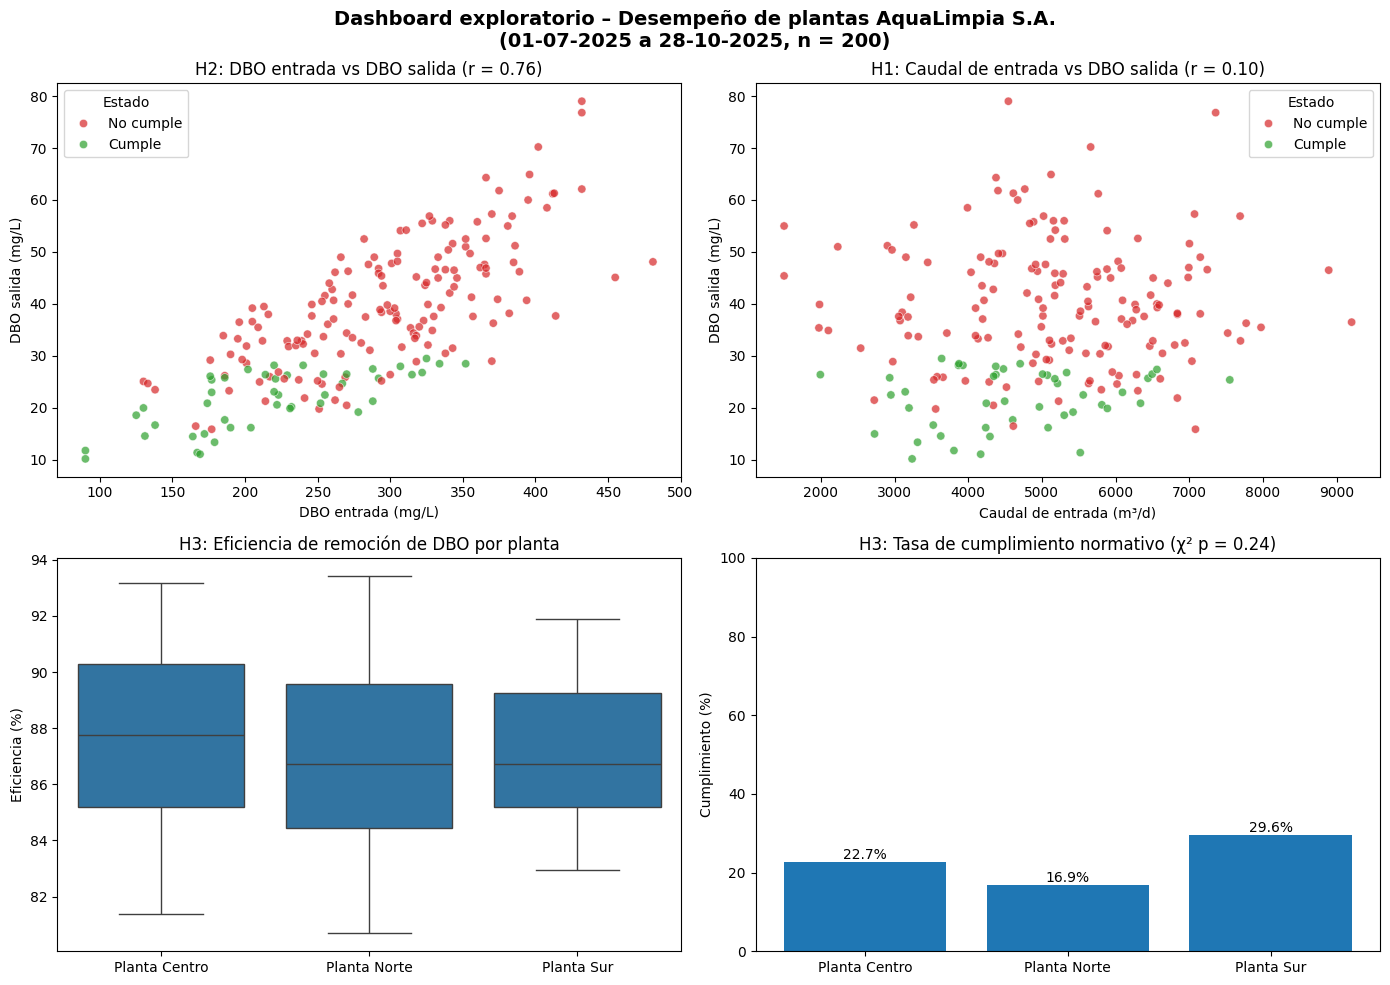

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('dashboard', exist_ok=True)

orden_plantas = sorted(df['planta'].unique())
estado = df['cumplimiento_norma'].map({0: 'No cumple', 1: 'Cumple'})
colores = {'No cumple': '#d62728', 'Cumple': '#2ca02c'}

r_carga = df['DBO_entrada_mg_L'].corr(df['DBO_salida_mg_L'])
r_caudal = df['caudal_entrada_m3_d'].corr(df['DBO_salida_mg_L'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dashboard exploratorio – Desempeño de plantas AquaLimpia S.A.\n'
             f'({df["fecha_registro"].min():%d-%m-%Y} a {df["fecha_registro"].max():%d-%m-%Y}, n = {len(df)})',
             fontsize=14, fontweight='bold')

# Panel 1 – H2: carga contaminante
sns.scatterplot(x=df['DBO_entrada_mg_L'], y=df['DBO_salida_mg_L'], hue=estado,
                palette=colores, alpha=0.7, ax=axes[0, 0])
axes[0, 0].set_title(f'H2: DBO entrada vs DBO salida (r = {r_carga:.2f})')
axes[0, 0].set_xlabel('DBO entrada (mg/L)')
axes[0, 0].set_ylabel('DBO salida (mg/L)')
axes[0, 0].legend(title='Estado')

# Panel 2 – H1: caudal
sns.scatterplot(x=df['caudal_entrada_m3_d'], y=df['DBO_salida_mg_L'], hue=estado,
                palette=colores, alpha=0.7, ax=axes[0, 1])
axes[0, 1].set_title(f'H1: Caudal de entrada vs DBO salida (r = {r_caudal:.2f})')
axes[0, 1].set_xlabel('Caudal de entrada (m³/d)')
axes[0, 1].set_ylabel('DBO salida (mg/L)')
axes[0, 1].legend(title='Estado')

# Panel 3 – H3: eficiencia por planta
sns.boxplot(data=df, x='planta', y='eficiencia_remocion_pct', order=orden_plantas, ax=axes[1, 0])
axes[1, 0].set_title('H3: Eficiencia de remoción de DBO por planta')
axes[1, 0].set_xlabel('')
axes[1, 0].set_ylabel('Eficiencia (%)')

# Panel 4 – H3: cumplimiento por planta
barras = axes[1, 1].bar(orden_plantas, resumen_plantas.loc[orden_plantas, 'tasa_cumplimiento_pct'],
                        color='#1f77b4')
axes[1, 1].bar_label(barras, fmt='%.1f%%')
axes[1, 1].set_title(f'H3: Tasa de cumplimiento normativo (χ² p = {p_valor:.2f})')
axes[1, 1].set_ylabel('Cumplimiento (%)')
axes[1, 1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig('dashboard/dashboard_exploratorio.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
os.makedirs('outputs', exist_ok=True)

# Umbrales de alerta (calculados desde los datos, no fijos)
umbral_carga = df['DBO_entrada_mg_L'].quantile(0.75)
umbral_eficiencia = df['eficiencia_remocion_pct'].quantile(0.10)

# --- Área de Operaciones ---
operaciones = df[['fecha_registro', 'planta', 'caudal_entrada_m3_d',
                  'DBO_entrada_mg_L', 'DBO_salida_mg_L', 'eficiencia_remocion_pct',
                  'energia_aeracion_kWh', 'lodos_generados_kg_d']].copy()

operaciones['alerta_carga_alta'] = operaciones['DBO_entrada_mg_L'] > umbral_carga
operaciones['alerta_eficiencia_baja'] = operaciones['eficiencia_remocion_pct'] < umbral_eficiencia
operaciones = operaciones.sort_values(['fecha_registro', 'planta'])
operaciones.to_excel('outputs/reporte_operaciones.xlsx', index=False)

# --- Área de Gestión Ambiental ---
ambiental = df[['fecha_registro', 'planta', 'DBO_salida_mg_L']].copy()
ambiental['estado_cumplimiento'] = df['cumplimiento_norma'].map({0: 'No cumple', 1: 'Cumple'})
ambiental = ambiental.sort_values(['fecha_registro', 'planta'])
ambiental.to_excel('outputs/reporte_gestion_ambiental.xlsx', index=False)

# Verificación
print(f'Umbral carga alta (P75): {umbral_carga:.1f} mg/L')
print(f'Umbral eficiencia baja (P10): {umbral_eficiencia:.2f} %')
print(operaciones[['alerta_carga_alta', 'alerta_eficiencia_baja']].sum())
print(ambiental['estado_cumplimiento'].value_counts())

Umbral carga alta (P75): 333.2 mg/L
Umbral eficiencia baja (P10): 82.92 %
alerta_carga_alta         50
alerta_eficiencia_baja    19
dtype: int64
estado_cumplimiento
No cumple    155
Cumple        45
Name: count, dtype: int64


In [13]:
validacion = pd.crosstab(operaciones['alerta_carga_alta'],
                         ambiental['estado_cumplimiento'],
                         margins=True, margins_name='Total')
validacion

estado_cumplimiento,Cumple,No cumple,Total
alerta_carga_alta,,,
False,43,107,150
True,2,48,50
Total,45,155,200
